Intelligent Network Incident Resolution System

In [1]:
!pip install -q langgraph langchain langchain-google-genai google-search-results

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 890.7 kB/s eta 0:00:00


In [24]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END,START
from langchain_google_genai import ChatGoogleGenerativeAI
from serpapi import GoogleSearch

In [ ]:
os.environ['GOOGLE_API_KEY']=''
os.environ['SERP_API_KEY']=''

In [6]:
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [41]:
# ================================
# STATE SCHEMA
# ================================

from typing import TypedDict


class HealthcareState(TypedDict):

    # User Input
    patient_input: str

    # Understanding Stage
    symptoms: list
    risk_level: str
    emergency_flag: bool
    distress_level: str
    medical_entities: list

    # Knowledge Retrieval Stage
    medical_guidelines: str
    drug_interactions: str
    historical_cases: str
    specialist_recommendation: str

    # Routing
    assigned_department: str

    # Care Coordination Outputs
    triage_summary: str
    diagnostic_tests: str
    followup_instructions: str
    emergency_notification: str

In [42]:
# ================================
# UNDERSTANDING STAGE NODES
# ================================

# 1. Symptom Extraction Node

def symptom_extraction_node(state: HealthcareState):

    patient_input = state["patient_input"]

    prompt = f"""
    Extract symptoms from the following patient statement.

    Patient Statement:
    {patient_input}

    Return symptoms as comma-separated values only.
    """

    response = llm.invoke(prompt)

    symptoms = response.content.split(",")

    symptoms = [s.strip().lower() for s in symptoms]

    return {
        "symptoms": symptoms
    }

In [43]:
# 2. Risk Scoring Node

def risk_scoring_node(state: HealthcareState):

    patient_input = state["patient_input"]

    prompt = f"""
    Analyze the medical risk level of this patient.

    Patient Statement:
    {patient_input}

    Possible Risk Levels:
    - low
    - medium
    - high
    - critical

    Return only the risk level.
    """

    response = llm.invoke(prompt)

    return {
        "risk_level": response.content.strip().lower()
    }

In [44]:
# 3. Emergency Detection Node

def emergency_detection_node(state: HealthcareState):

    patient_input = state["patient_input"]

    emergency_keywords = [
        "chest pain",
        "shortness of breath",
        "unconscious",
        "severe bleeding",
        "stroke",
        "heart attack"
    ]

    emergency = any(
        keyword in patient_input.lower()
        for keyword in emergency_keywords
    )

    return {
        "emergency_flag": emergency
    }

In [45]:
# 4. Distress Analysis Node

def distress_analysis_node(state: HealthcareState):

    patient_input = state["patient_input"]

    prompt = f"""
    Analyze emotional distress level of this patient.

    Patient Statement:
    {patient_input}

    Return:
    - calm
    - worried
    - distressed
    - panic

    Return only one value.
    """

    response = llm.invoke(prompt)

    return {
        "distress_level": response.content.strip().lower()
    }

In [46]:
# 5. Medical Entity Recognition Node

def medical_entity_node(state: HealthcareState):

    patient_input = state["patient_input"]

    prompt = f"""
    Identify important medical entities from this statement.

    Patient Statement:
    {patient_input}

    Return comma-separated entities only.
    """

    response = llm.invoke(prompt)

    entities = response.content.split(",")

    entities = [e.strip().lower() for e in entities]

    return {
        "medical_entities": entities
    }

In [47]:
# ================================
# UNDERSTANDING MERGE NODE
# ================================

def understanding_merge_node(state: HealthcareState):

    print("Understanding Stage Completed")

    return {}

In [48]:
# ================================
# DUMMY KNOWLEDGE BASES
# ================================

medical_guidelines_db = {

    "chest pain": "Immediate ECG and cardiac monitoring recommended.",

    "fever": "Hydration and temperature monitoring advised.",

    "skin rash": "Check allergic reaction history.",

    "dizziness": "Neurological assessment recommended."
}

In [49]:
drug_interaction_db = {

    "aspirin": "Avoid with blood thinners.",

    "ibuprofen": "May cause gastric irritation.",

    "paracetamol": "Generally safe within dosage limits."
}

In [50]:
historical_cases_db = {

    "chest pain": "Similar previous cardiac emergency cases found.",

    "blurred vision": "Neurology referrals common.",

    "skin rash": "Allergic medication reactions detected in past cases."
}

In [51]:
specialist_db = {

    "chest pain": "Cardiology",

    "shortness of breath": "Pulmonology",

    "blurred vision": "Neurology",

    "skin rash": "Dermatology",

    "dizziness": "Neurology"
}

In [52]:
# ================================
# KNOWLEDGE RETRIEVAL NODES
# ================================

# 1. Medical Guideline Retrieval

def guideline_retrieval_node(state: HealthcareState):

    symptoms = state["symptoms"]

    guidelines = []

    for symptom in symptoms:

        if symptom in medical_guidelines_db:
            guidelines.append(
                medical_guidelines_db[symptom]
            )

    return {
        "medical_guidelines": " | ".join(guidelines)
    }

In [53]:
# 2. Drug Interaction Retrieval

def drug_interaction_node(state: HealthcareState):

    entities = state["medical_entities"]

    interactions = []

    for entity in entities:

        if entity in drug_interaction_db:
            interactions.append(
                drug_interaction_db[entity]
            )

    if not interactions:
        interactions.append("No major drug interactions found.")

    return {
        "drug_interactions": " | ".join(interactions)
    }

In [54]:
# 2. Drug Interaction Retrieval

def drug_interaction_node(state: HealthcareState):

    entities = state["medical_entities"]

    interactions = []

    for entity in entities:

        if entity in drug_interaction_db:
            interactions.append(
                drug_interaction_db[entity]
            )

    if not interactions:
        interactions.append("No major drug interactions found.")

    return {
        "drug_interactions": " | ".join(interactions)
    }

In [55]:
# 3. Historical Case Retrieval

def historical_case_node(state: HealthcareState):

    symptoms = state["symptoms"]

    cases = []

    for symptom in symptoms:

        if symptom in historical_cases_db:
            cases.append(
                historical_cases_db[symptom]
            )

    return {
        "historical_cases": " | ".join(cases)
    }

In [56]:
# 4. Specialist Recommendation Retrieval

def specialist_recommendation_node(state: HealthcareState):

    symptoms = state["symptoms"]

    specialists = []

    for symptom in symptoms:

        if symptom in specialist_db:
            specialists.append(
                specialist_db[symptom]
            )

    if not specialists:
        specialists.append("General Physician")

    return {
        "specialist_recommendation": ", ".join(set(specialists))
    }

In [57]:
# ================================
# RETRIEVAL MERGE NODE
# ================================

def retrieval_merge_node(state: HealthcareState):

    print("Knowledge Retrieval Completed")

    return {}

In [58]:
# ================================
# AGENT NODES
# ================================

# 1. Emergency Agent

def emergency_agent_node(state: HealthcareState):

    print("Emergency Agent Activated")

    return {
        "assigned_department": "Emergency Department"
    }

In [59]:
# 2. Cardiology Agent

def cardiology_agent_node(state: HealthcareState):

    print("Cardiology Agent Activated")

    return {
        "assigned_department": "Cardiology Department"
    }

In [60]:
# 3. Neurology Agent

def neurology_agent_node(state: HealthcareState):

    print("Neurology Agent Activated")

    return {
        "assigned_department": "Neurology Department"
    }

In [61]:
# 4. Pharmacy Agent

def pharmacy_agent_node(state: HealthcareState):

    print("Pharmacy Review Agent Activated")

    return {
        "assigned_department": "Pharmacy Department"
    }

In [62]:
# 5. General Physician Agent

def general_physician_node(state: HealthcareState):

    print("General Physician Agent Activated")

    return {
        "assigned_department": "General Physician"
    }

In [63]:
# ================================
# CONDITIONAL ROUTER
# ================================

def healthcare_router(state: HealthcareState):

    symptoms = state["symptoms"]

    emergency = state["emergency_flag"]

    if emergency:
        return "emergency_agent"

    elif "chest pain" in symptoms:
        return "cardiology_agent"

    elif "blurred vision" in symptoms:
        return "neurology_agent"

    elif "skin rash" in symptoms:
        return "pharmacy_agent"

    else:
        return "general_physician_agent"

In [64]:
# ================================
# CARE COORDINATION NODES
# ================================

# 1. Triage Summary

def triage_summary_node(state: HealthcareState):

    summary = f"""
    Symptoms:
    {state['symptoms']}

    Risk Level:
    {state['risk_level']}

    Assigned Department:
    {state['assigned_department']}
    """

    return {
        "triage_summary": summary
    }

In [65]:
# 2. Diagnostic Test Recommendation

def diagnostic_test_node(state: HealthcareState):

    symptoms = state["symptoms"]

    if "chest pain" in symptoms:
        tests = "ECG, Troponin Test"

    elif "dizziness" in symptoms:
        tests = "MRI Scan, Neurological Evaluation"

    else:
        tests = "General Blood Test"

    return {
        "diagnostic_tests": tests
    }

In [66]:
# 3. Follow-up Instructions

def followup_instruction_node(state: HealthcareState):

    instructions = f"""
    Please follow guidance from:
    {state['assigned_department']}

    Follow medication and diagnostic advice carefully.
    """

    return {
        "followup_instructions": instructions
    }

In [67]:
# 4. Emergency Notification

def emergency_notification_node(state: HealthcareState):

    if state["emergency_flag"]:

        notification = """
        ALERT:
        Emergency desk notified immediately.
        """

    else:

        notification = "No emergency escalation required."

    return {
        "emergency_notification": notification
    }

In [72]:
graph = StateGraph(HealthcareState)
# =========================================
# ADD UNDERSTANDING STAGE NODES
# =========================================

graph.add_node(
    "symptom_extraction",
    symptom_extraction_node
)

graph.add_node(
    "risk_scoring",
    risk_scoring_node
)

graph.add_node(
    "emergency_detection",
    emergency_detection_node
)

graph.add_node(
    "distress_analysis",
    distress_analysis_node
)

graph.add_node(
    "medical_entity_recognition",
    medical_entity_node
)

graph.add_node(
    "understanding_merge",
    understanding_merge_node
)

# =========================================
# ADD KNOWLEDGE RETRIEVAL NODES
# =========================================

graph.add_node(
    "guideline_retrieval",
    guideline_retrieval_node
)

graph.add_node(
    "drug_interaction_check",
    drug_interaction_node
)

graph.add_node(
    "historical_case_lookup",
    historical_case_node
)

graph.add_node(
    "specialist_recommendation",
    specialist_recommendation_node
)

graph.add_node(
    "retrieval_merge",
    retrieval_merge_node
)

# =========================================
# ADD AGENT NODES
# =========================================

graph.add_node(
    "emergency_agent",
    emergency_agent_node
)

graph.add_node(
    "cardiology_agent",
    cardiology_agent_node
)

graph.add_node(
    "neurology_agent",
    neurology_agent_node
)

graph.add_node(
    "pharmacy_agent",
    pharmacy_agent_node
)

graph.add_node(
    "general_physician_agent",
    general_physician_node
)

# =========================================
# ADD CARE COORDINATION NODES
# =========================================

graph.add_node(
    "triage_summary",
    triage_summary_node
)

graph.add_node(
    "diagnostic_tests",
    diagnostic_test_node
)

graph.add_node(
    "followup_instructions",
    followup_instruction_node
)

graph.add_node(
    "emergency_notification",
    emergency_notification_node
)

# =========================================
# PARALLEL UNDERSTANDING STAGE
# =========================================

graph.add_edge(
    START,
    "symptom_extraction"
)

graph.add_edge(
    START,
    "risk_scoring"
)

graph.add_edge(
    START,
    "emergency_detection"
)

graph.add_edge(
    START,
    "distress_analysis"
)

graph.add_edge(
    START,
    "medical_entity_recognition"
)

# =========================================
# UNDERSTANDING MERGE
# =========================================

graph.add_edge(
    "symptom_extraction",
    "understanding_merge"
)

graph.add_edge(
    "risk_scoring",
    "understanding_merge"
)

graph.add_edge(
    "emergency_detection",
    "understanding_merge"
)

graph.add_edge(
    "distress_analysis",
    "understanding_merge"
)

graph.add_edge(
    "medical_entity_recognition",
    "understanding_merge"
)

# =========================================
# PARALLEL KNOWLEDGE RETRIEVAL
# =========================================

graph.add_edge(
    "understanding_merge",
    "guideline_retrieval"
)

graph.add_edge(
    "understanding_merge",
    "drug_interaction_check"
)

graph.add_edge(
    "understanding_merge",
    "historical_case_lookup"
)

graph.add_edge(
    "understanding_merge",
    "specialist_recommendation"
)

# =========================================
# RETRIEVAL MERGE
# =========================================

graph.add_edge(
    "guideline_retrieval",
    "retrieval_merge"
)

graph.add_edge(
    "drug_interaction_check",
    "retrieval_merge"
)

graph.add_edge(
    "historical_case_lookup",
    "retrieval_merge"
)

graph.add_edge(
    "specialist_recommendation",
    "retrieval_merge"
)

# =========================================
# CONDITIONAL ROUTING
# =========================================

graph.add_conditional_edges(
    "retrieval_merge",
    healthcare_router,
    {
        "emergency_agent": "emergency_agent",

        "cardiology_agent": "cardiology_agent",

        "neurology_agent": "neurology_agent",

        "pharmacy_agent": "pharmacy_agent",

        "general_physician_agent":
        "general_physician_agent"
    }
)

# =========================================
# EMERGENCY AGENT OUTPUTS -STOP EARLY
# =========================================

graph.add_edge(
    "emergency_agent",
    "emergency_notification"
)

graph.add_edge(
    "emergency_notification",
    END
)

# =========================================
# CARDIOLOGY AGENT OUTPUTS
# =========================================

graph.add_edge(
    "cardiology_agent",
    "triage_summary"
)

graph.add_edge(
    "cardiology_agent",
    "diagnostic_tests"
)

graph.add_edge(
    "cardiology_agent",
    "followup_instructions"
)

graph.add_edge(
    "cardiology_agent",
    "emergency_notification"
)

# =========================================
# NEUROLOGY AGENT OUTPUTS
# =========================================

graph.add_edge(
    "neurology_agent",
    "triage_summary"
)

graph.add_edge(
    "neurology_agent",
    "diagnostic_tests"
)

graph.add_edge(
    "neurology_agent",
    "followup_instructions"
)

graph.add_edge(
    "neurology_agent",
    "emergency_notification"
)

# =========================================
# PHARMACY AGENT OUTPUTS
# =========================================

graph.add_edge(
    "pharmacy_agent",
    "triage_summary"
)

graph.add_edge(
    "pharmacy_agent",
    "diagnostic_tests"
)

graph.add_edge(
    "pharmacy_agent",
    "followup_instructions"
)

graph.add_edge(
    "pharmacy_agent",
    "emergency_notification"
)

# =========================================
# GENERAL PHYSICIAN OUTPUTS
# =========================================

graph.add_edge(
    "general_physician_agent",
    "triage_summary"
)

graph.add_edge(
    "general_physician_agent",
    "diagnostic_tests"
)

graph.add_edge(
    "general_physician_agent",
    "followup_instructions"
)

graph.add_edge(
    "general_physician_agent",
    "emergency_notification"
)

# =========================================
# END WORKFLOW
# =========================================

graph.add_edge(
    "triage_summary",
    END
)

graph.add_edge(
    "diagnostic_tests",
    END
)

graph.add_edge(
    "followup_instructions",
    END
)


workflow = graph.compile()

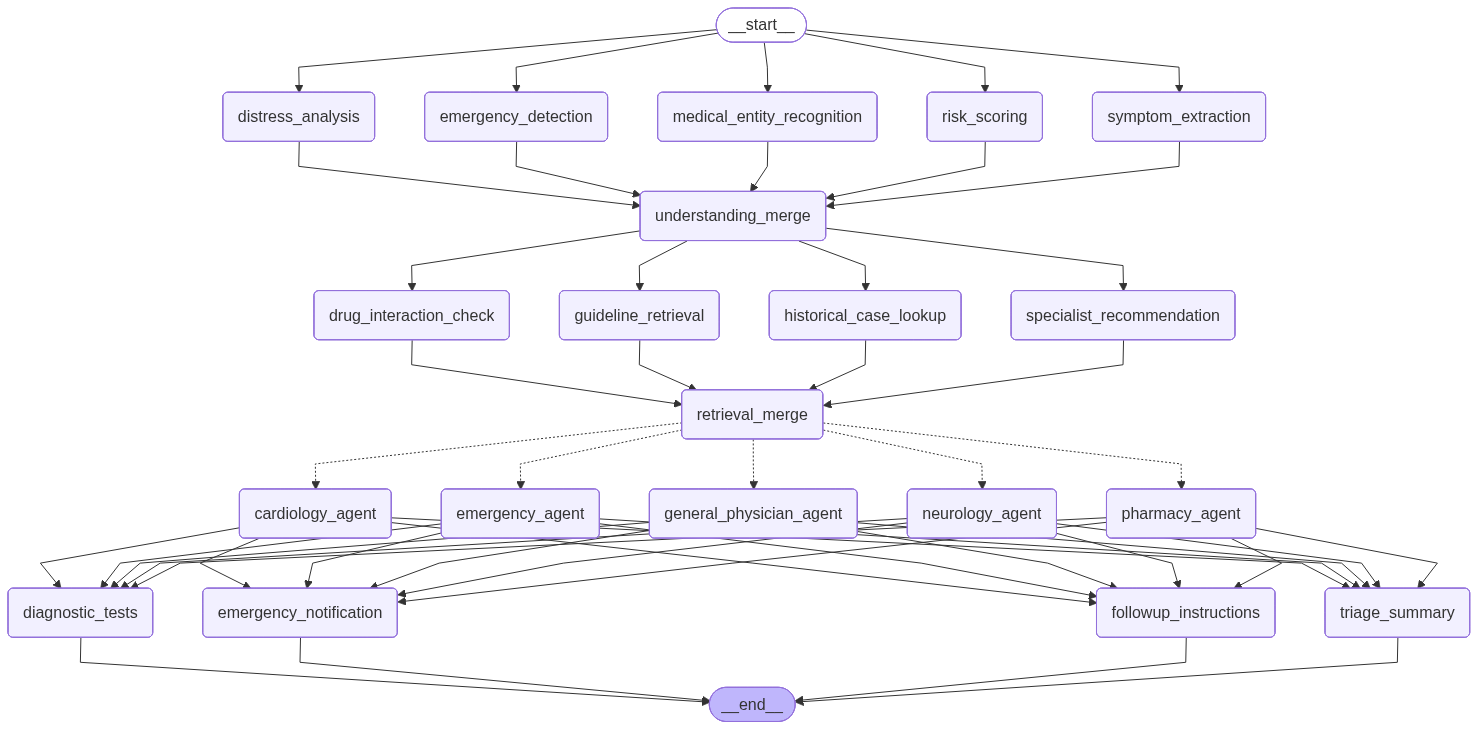

In [70]:
workflow

In [73]:
result = workflow.invoke(
    {
        "patient_input":
        "Chest pain and shortness of breath"
    }
)
print(result)

Understanding Stage Completed
Knowledge Retrieval Completed
Emergency Agent Activated
{'patient_input': 'Chest pain and shortness of breath', 'symptoms': ['chest pain', 'shortness of breath'], 'risk_level': 'critical', 'emergency_flag': True, 'distress_level': 'distressed', 'medical_entities': ['chest pain', 'shortness of breath'], 'medical_guidelines': 'Immediate ECG and cardiac monitoring recommended.', 'drug_interactions': 'No major drug interactions found.', 'historical_cases': 'Similar previous cardiac emergency cases found.', 'specialist_recommendation': 'Pulmonology, Cardiology', 'assigned_department': 'Emergency Department', 'emergency_notification': '\n        ALERT:\n        Emergency desk notified immediately.\n        '}
